In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PowerTransformer

np.random.seed(42)

n = 2000

df = pd.DataFrame({
    "area": np.random.lognormal(mean=5, sigma=0.6, size=n),
    "age": np.random.randint(1, 50, size=n)
})

noise = np.random.normal(0, 0.25, n)

df["price"] = np.exp(
    10 + 0.7 * np.log(df["area"]) - 0.02 * df["age"] + noise
)

df.head()

,area,age,price
0,199.942233,30,3.653661e+05
1,136.597879,31,3.441611e+05
2,218.899588,38,4.652381e+05
3,370.116534,11,1.431469e+06
4,128.960735,35,3.294621e+05


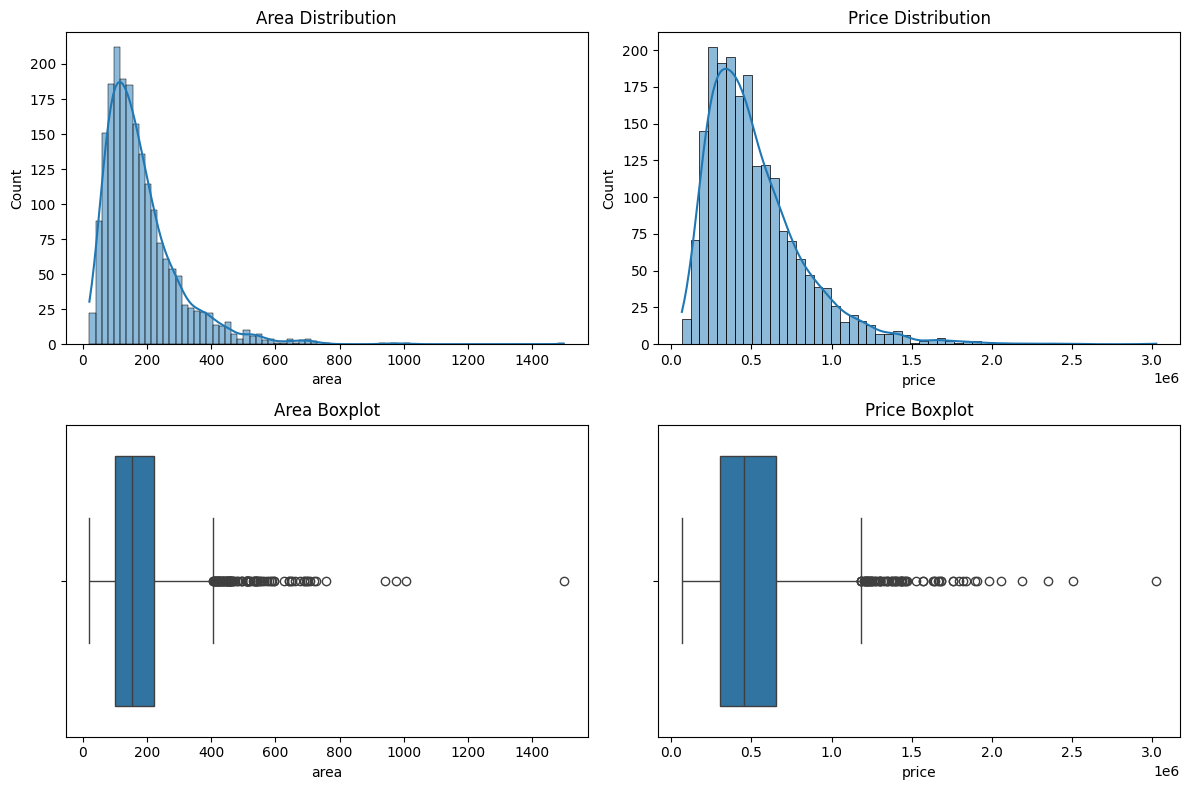

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["area"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Area Distribution")

sns.histplot(df["price"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Price Distribution")

sns.boxplot(x=df["area"], ax=axes[1, 0])
axes[1, 0].set_title("Area Boxplot")

sns.boxplot(x=df["price"], ax=axes[1, 1])
axes[1, 1].set_title("Price Boxplot")

plt.tight_layout()
plt.show()

In [3]:
skewness = df[["area", "age", "price"]].skew()

print(skewness)

area     2.414989
age      0.008661
price    1.806100
dtype: float64


In [4]:
df["log_area"] = np.log1p(df["area"])
df["log_price"] = np.log(df["price"])

df["sqrt_area"] = np.sqrt(df["area"])

In [5]:
transformer = PowerTransformer(
    method="yeo-johnson",
    standardize=False
)

df["yeo_johnson_area"] = transformer.fit_transform(
    df[["area"]]
)

In [6]:
columns = [
    "area",
    "log_area",
    "sqrt_area",
    "yeo_johnson_area",
    "price",
    "log_price"
]

print(df[columns].skew().sort_values())

log_price          -0.016463
yeo_johnson_area   -0.000197
log_area            0.046700
sqrt_area           1.005157
price               1.806100
area                2.414989
dtype: float64


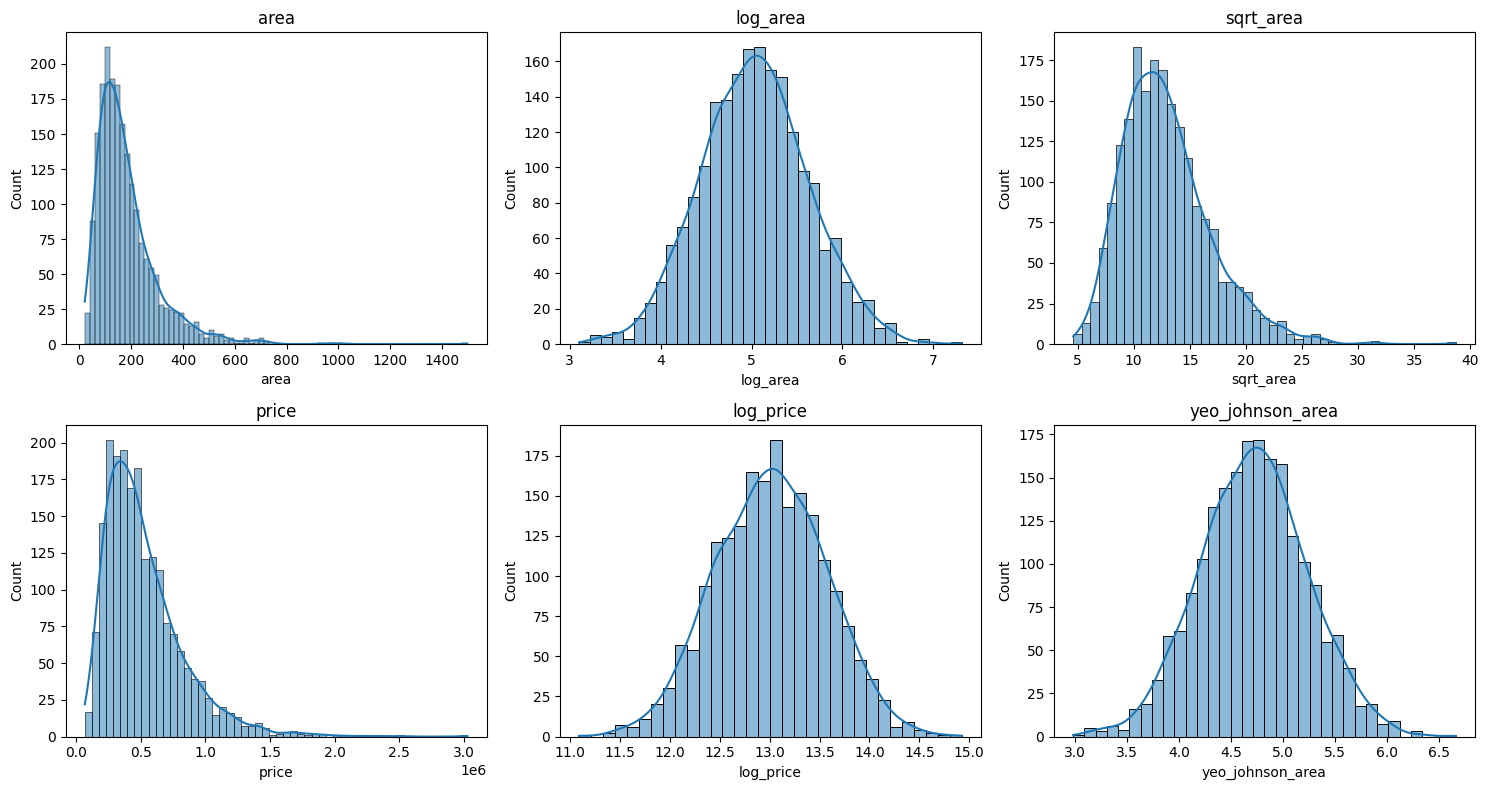

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

columns = [
    "area", "log_area", "sqrt_area",
    "price", "log_price", "yeo_johnson_area"
]

for ax, column in zip(axes.flatten(), columns):
    sns.histplot(df[column], kde=True, ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()